# Regression & Optimisation — Linear Regression, Gradient Descent, Regularisation (Ridge / Lasso)

*Part of the ML Course Reference Series.*

## Q15: What is Linear Regression (Ordinary Least Squares)?

OLS finds the line (or hyperplane) that minimises the sum of squared residuals:

```
Loss = Σ (y_i - ŷ_i)²
```

The closed-form solution is:
```
w = (XᵀX)⁻¹ Xᵀy
```

This has an exact answer — no iterations needed (unlike gradient descent). However it becomes slow when the number of features is very large.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print('MAE: ', round(mean_absolute_error(y_test, y_pred), 2))
print('R²:  ', round(r2_score(y_test, y_pred), 3))

# OLS closed form (manual, 1-feature example)
X_simple = X_diab[['bmi']].values
X_b = np.hstack([np.ones((len(X_simple), 1)), X_simple])  # add bias column
w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_diab.values
print(f'\nOLS (manual) — intercept: {w_ols[0]:.2f}, bmi coef: {w_ols[1]:.2f}')

MAE:  42.79
R²:   0.453

OLS (manual) — intercept: 152.13, bmi coef: 949.44


## Q16: What is Gradient Descent?

An iterative optimisation algorithm. At each step, move the weights in the direction that decreases the loss most (the negative gradient):

```
w := w - α × ∇Loss(w)
```

Where α is the **learning rate**:
- Too small → converges slowly
- Too large → overshoots, may diverge

Used when the matrix inversion of OLS would be too expensive (many features) or when there's no closed form (neural networks).

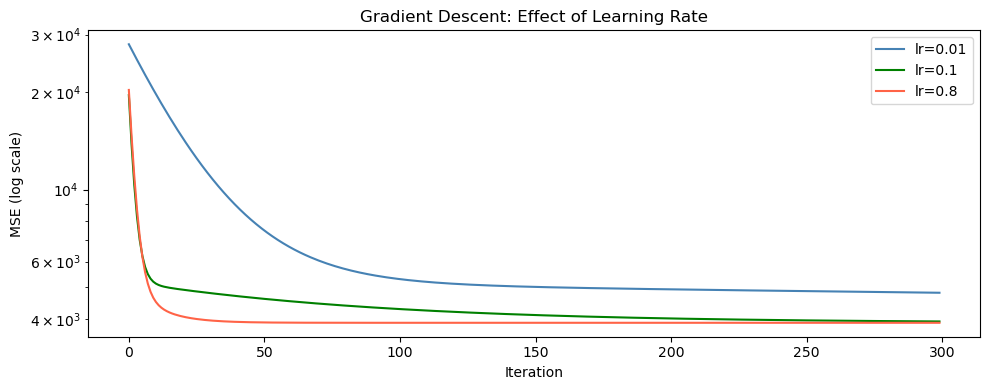

In [21]:
# Gradient descent for linear regression (from scratch)
X_raw = X_diab[['bmi']].values
X_norm = (X_raw - X_raw.min()) / (X_raw.max() - X_raw.min())  # normalise to [0,1]
X_b = np.hstack([np.ones((len(X_norm), 1)), X_norm])
y = y_diab.values

def mse(w, X, y):
    return np.mean((X @ w - y) ** 2)

plt.figure(figsize=(10, 4))

for lr_val, color in [(0.01, 'steelblue'), (0.1, 'green'), (0.8, 'tomato')]:
    w = np.zeros(2)
    losses = []
    for _ in range(300):
        grad = (2 / len(y)) * X_b.T @ (X_b @ w - y)
        w = w - lr_val * grad
        losses.append(mse(w, X_b, y))
    plt.plot(losses, label=f'lr={lr_val}', color=color)

plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('MSE (log scale)')
plt.title('Gradient Descent: Effect of Learning Rate')
plt.legend()
plt.tight_layout()
plt.show()

## Q17: What is Regularisation (Ridge / Lasso)?

Regularisation adds a penalty to the loss function to prevent large coefficients (overfitting):

| Method | Penalty | Effect |
|---|---|---|
| **Ridge (L2)** | `α × Σ w²` | Shrinks all weights toward zero, keeps all features |
| **Lasso (L1)** | `α × Σ |w|` | Forces some weights exactly to zero — **feature selection** |
| **ElasticNet** | mix of L1 + L2 | Combines both |

`alpha` controls strength. Higher alpha → more regularisation → simpler model.

In [22]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

for alpha in [0.01, 1.0, 10.0]:
    pipe_ridge = Pipeline([('scl', StandardScaler()), ('reg', Ridge(alpha=alpha))])
    pipe_lasso = Pipeline([('scl', StandardScaler()), ('reg', Lasso(alpha=alpha))])

    r_ridge = cross_val_score(pipe_ridge, X_diab, y_diab, cv=5, scoring='r2').mean()
    r_lasso = cross_val_score(pipe_lasso, X_diab, y_diab, cv=5, scoring='r2').mean()
    print(f'alpha={alpha:5.2f}  Ridge R²={r_ridge:.3f}  Lasso R²={r_lasso:.3f}')

# Lasso with enough alpha zeroes some coefficients entirely
lasso = Pipeline([('scl', StandardScaler()), ('reg', Lasso(alpha=1.0))])
lasso.fit(X_diab, y_diab)
coef = pd.Series(lasso.named_steps['reg'].coef_, index=X_diab.columns)
print('\nLasso coefficients (0 = feature dropped):')
print(coef.round(2))

alpha= 0.01  Ridge R²=0.482  Lasso R²=0.482
alpha= 1.00  Ridge R²=0.482  Lasso R²=0.482
alpha=10.00  Ridge R²=0.481  Lasso R²=0.439

Lasso coefficients (0 = feature dropped):
age    -0.00
sex    -9.32
bmi    24.83
bp     14.09
s1     -4.84
s2     -0.00
s3    -10.62
s4      0.00
s5     24.42
s6      2.56
dtype: float64


## Q17b: How do Ridge and Lasso actually differ — geometry and interpretation?

**Ridge (L2)** constrains weights to a sphere: all coefficients shrink proportionally toward zero, none reach exactly zero. Good when **all features matter a little**.

**Lasso (L1)** constrains weights to a diamond: the corners sit on the axes, so the optimum often lands exactly on a corner — meaning **some coefficients become exactly zero** (automatic feature selection). Good when you suspect many features are irrelevant.

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty | $\\alpha \\sum w_i^2$ | $\\alpha \\sum |w_i|$ |
| Zeroes weights? | No | Yes |
| Use when | All features relevant | Many irrelevant features |

**`alpha`:** higher → more regularisation → simpler model. Choose via `RidgeCV`/`LassoCV` or `GridSearchCV`.

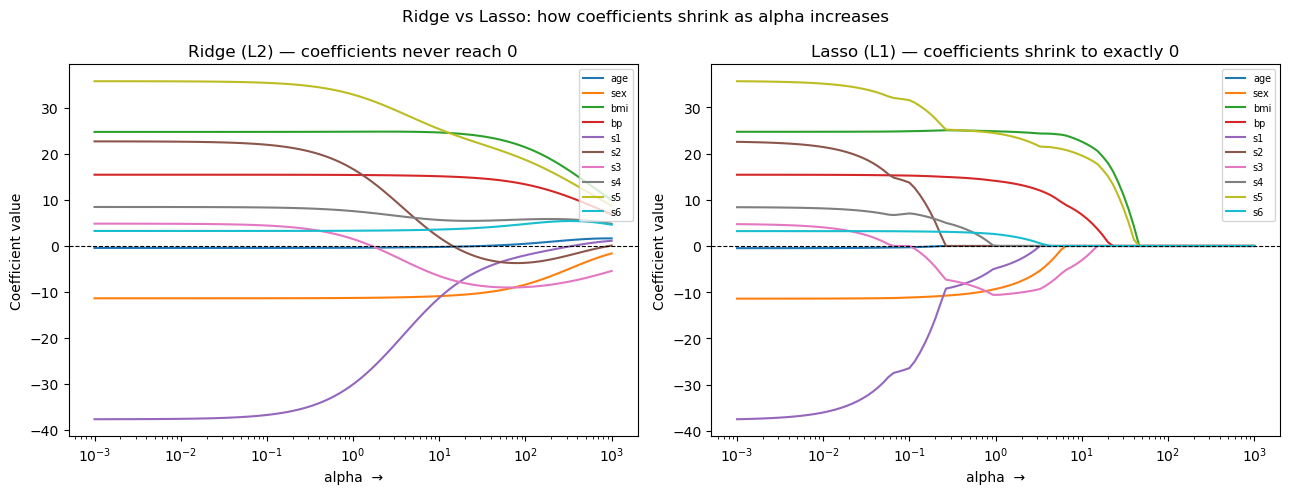

Lasso (alpha=0.5): 8 kept, 2 zeroed
Kept:   ['sex', 'bmi', 'bp', 's1', 's3', 's4', 's5', 's6']
Zeroed: ['age', 's2']


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes

X_d, y_d = load_diabetes(as_frame=True, return_X_y=True)
feature_names = X_d.columns.tolist()
X_sc = StandardScaler().fit_transform(X_d)

alphas = np.logspace(-3, 3, 100)
ridge_coefs = np.array([Ridge(alpha=a).fit(X_sc, y_d).coef_ for a in alphas])
lasso_coefs = np.array([Lasso(alpha=a, max_iter=5000).fit(X_sc, y_d).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, coefs, title in [
        (axes[0], ridge_coefs, 'Ridge (L2) — coefficients never reach 0'),
        (axes[1], lasso_coefs, 'Lasso (L1) — coefficients shrink to exactly 0')]:
    for j, name in enumerate(feature_names):
        ax.plot(alphas, coefs[:, j], label=name)
    ax.set_xscale('log')
    ax.set_xlabel('alpha  →')
    ax.set_ylabel('Coefficient value')
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend(fontsize=7, loc='upper right')
plt.suptitle('Ridge vs Lasso: how coefficients shrink as alpha increases')
plt.tight_layout()
plt.show()

# Which features does Lasso zero out?
lasso_fit = Lasso(alpha=0.5, max_iter=5000).fit(X_sc, y_d)
kept = [(n, c) for n, c in zip(feature_names, lasso_fit.coef_) if c != 0]
zeroed = [(n, c) for n, c in zip(feature_names, lasso_fit.coef_) if c == 0]
print(f'Lasso (alpha=0.5): {len(kept)} kept, {len(zeroed)} zeroed')
print('Kept:  ', [n for n, _ in kept])
print('Zeroed:', [n for n, _ in zeroed])

---
# 5. Model Evaluation — Classification